# 🌿 Reto 4 – Análisis con método numérico

## 🎯 Objetivo
Aplicar el método de diferencias finitas para analizar el cambio de variables ambientales y su impacto en la calidad del agua.

---

## 📥 Carga de datos
Se utiliza el dataset previamente procesado.

 1. CARGAR LOS DATOS

In [16]:
import pandas as pd

datos = pd.read_csv("../datos/datos_experimentales.csv")

datos.head()


,punto,dureza,conductividad,ph,oxigeno,temperatura
0,Rio mancilla 1,85,160,6.8,7.4,18
1,Rio Mancilla 2,230,320,6.1,5.6,19
2,Rio Botello,190,270,6.0,5.3,20
3,Rio Cartagenita,360,520,6.4,3.2,22


VER LOS DATOS

In [17]:
print(datos)

             punto  dureza  conductividad   ph  oxigeno  temperatura
0   Rio mancilla 1      85            160  6.8      7.4           18
1   Rio Mancilla 2     230            320  6.1      5.6           19
2      Rio Botello     190            270  6.0      5.3           20
3  Rio Cartagenita     360            520  6.4      3.2           22


2.RELACIÓN ENTRE TEMPERATURA Y OXÍGENO

In [18]:
print(datos[["temperatura", "oxigeno"]])

   temperatura  oxigeno
0           18      7.4
1           19      5.6
2           20      5.3
3           22      3.2


clasificacion 

In [19]:
datos["estado"] = datos.apply(
    lambda x: "malo" if x["oxigeno"] < 5 else "bueno",
    axis=1
)

print(datos)

             punto  dureza  conductividad   ph  oxigeno  temperatura estado
0   Rio mancilla 1      85            160  6.8      7.4           18  bueno
1   Rio Mancilla 2     230            320  6.1      5.6           19  bueno
2      Rio Botello     190            270  6.0      5.3           20  bueno
3  Rio Cartagenita     360            520  6.4      3.2           22   malo


In [20]:
def evaluar(temp, oxi):
    if oxi < 5:
        return "bajo oxígeno"
    elif temp > 22:
        return "alta temperatura"
    else:
        return "normal"

In [21]:
datos["evaluacion"] = datos.apply(lambda x: evaluar(x["temperatura"], x["oxigeno"]), axis=1)

print(datos)

             punto  dureza  conductividad   ph  oxigeno  temperatura estado  \
0   Rio mancilla 1      85            160  6.8      7.4           18  bueno   
1   Rio Mancilla 2     230            320  6.1      5.6           19  bueno   
2      Rio Botello     190            270  6.0      5.3           20  bueno   
3  Rio Cartagenita     360            520  6.4      3.2           22   malo   

     evaluacion  
0        normal  
1        normal  
2        normal  
3  bajo oxígeno  


3.MÉTODO NUMÉRICO diferencias finitas

Es un método que sirve para ver cómo cambia un dato comparándolo con el anterior.
nuevo valor - valor anterior

In [22]:
datos["cambio_oxigeno"] = datos["oxigeno"].diff()

print(datos)

             punto  dureza  conductividad   ph  oxigeno  temperatura estado  \
0   Rio mancilla 1      85            160  6.8      7.4           18  bueno   
1   Rio Mancilla 2     230            320  6.1      5.6           19  bueno   
2      Rio Botello     190            270  6.0      5.3           20  bueno   
3  Rio Cartagenita     360            520  6.4      3.2           22   malo   

     evaluacion  cambio_oxigeno  
0        normal             NaN  
1        normal            -1.8  
2        normal            -0.3  
3  bajo oxígeno            -2.1  


In [23]:
print("Temperatura promedio:", datos["temperatura"].mean())
print("Oxígeno promedio:", datos["oxigeno"].mean())

Temperatura promedio: 19.75
Oxígeno promedio: 5.375


In [24]:
if datos["oxigeno"].mean() < 5:
    print("El sistema está en riesgo")
else:
    print("El sistema está estable")

El sistema está estable


# Teórico: el oxígeno baja cuando sube la temperatura
# Experimental: el oxigwno disminuye a medida que la temperatura aumenta 

<Axes: xlabel='temperatura', ylabel='oxigeno'>

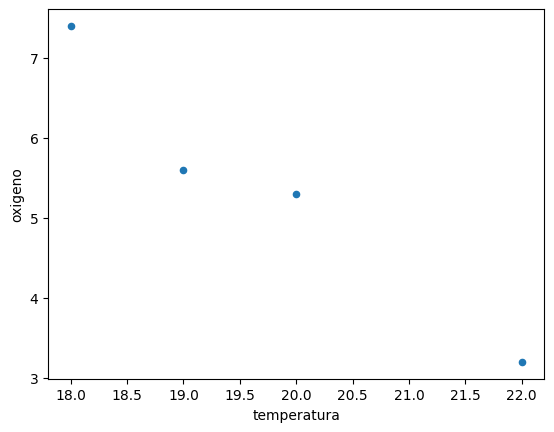

In [26]:
datos.plot(x="temperatura", y="oxigeno", kind="scatter")

## analisis 
e realizó un análisis de los datos experimentales relacionando la temperatura con el oxígeno disuelto.

A través de la gráfica de dispersión, se observó el comportamiento de ambas variables. Los puntos muestran que, en general, cuando la temperatura aumenta, el nivel de oxígeno tiende a disminuir.

Esto indica que existe una relación inversa entre la temperatura y el oxígeno, lo cual coincide con lo esperado teóricamente.

Además, se analizaron los cambios entre mediciones utilizando diferencias entre valores consecutivos, lo que permitió identificar cómo varía el oxígeno a lo largo de los datos.

En conclusión, los resultados experimentales apoyan la teoría, ya que el aumento de la temperatura afecta negativamente la cantidad de oxígeno en el sistema.